In [7]:
#Basic Eval script
#We need to implement same logic as with the Evaluation script of BenchMARL
#Reviewing BenchMARL we know the following:
#The seed for evaluation is set according to the seed we specify in the command line
#We then conduct 100 episodes of evaluation using this seed
import functools
import random
from copy import copy
import pettingzoo
import numpy as np
import gymnasium as gym
from gymnasium.spaces import Discrete, MultiDiscrete
from pettingzoo import ParallelEnv
import matplotlib.pyplot as plt
from pettingzoo.test import parallel_api_test
from gymnasium import spaces
from Multi_Agent_Environment_Flat import CustomEnvironmentFlat
env = CustomEnvironmentFlat()
parallel_api_test(env, num_cycles=1_000_000)


Passed Parallel API test


In [34]:
#Current BaselineCGR model
#Definitely not perfect, may not stop transmitting after agent is out of packets (this is bad as it will cause excess collisions but even without this is a massive problem)

def BaselineCGR(env):
    observations,info = env.reset()
    
    all_agents = ["satellite1", "satellite2", "satellite3"]
    
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    total_rewards=0
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        #Could get this from observations but no time
        satellite2_info=info['satellite2']
        contact_plan=satellite2_info['True_Contact_Matrix']
        #print(contact_plan)
        #print(observations)
        obs=observations['satellite2']
        timestep=obs[153]
        #Next we check LoS to determine if we try to send
        availability=np.zeros(3,)
        for i in range(0,len(availability)):
            availability[i]=contact_plan[int(timestep)][2+i]
        counter=0
        actions={agent:None for agent in all_agents}
        for agent in all_agents:
            if availability[counter]==1:
                
                actions[agent]=1
            else:
                actions[agent]=0
            counter+=1
        print(actions)
        observations, rewards, terminated, truncated, info = env.step(actions)
        for a in all_agents:
            total_rewards+=rewards[a]
    #Extract metrics
    satellite1_info=info['satellite1']
    Overall_Delivered_Packets=satellite1_info['Delivered_Packets']
    Overall_Excess_Energy=satellite1_info['Total_Energy_Expended']
    Overall_Number_of_Contacts_Used=satellite1_info['Total_Number_of_Contacts_Used']
    num_of_collisions=satellite1_info['Number_of_Collisions']
    total_initial_data_volume=satellite1_info['Total_Initial_Satellite_Data_Volume']
    
    agent_specific_delivered_packets=[]
    agent_specific_excess_energy=[]
    agent_specific_num_of_contacts=[]
    agent_specific_initial_data_volume=[]
    #Extract agent specific metrics
    for a in all_agents:
        sat_info=info[a]
        agent_specific_delivered_packets.append(sat_info['satellite_delivered_packets'])
        agent_specific_excess_energy.append(sat_info['satellite_energy_expended'])
        agent_specific_num_of_contacts.append(sat_info['satellite_number_of_contacts_used'])
        agent_specific_initial_data_volume.append(sat_info['satellite_initial_data_volume'])
        
    env.close()
    return total_rewards,Overall_Delivered_Packets,Overall_Excess_Energy,Overall_Number_of_Contacts_Used,agent_specific_delivered_packets,agent_specific_excess_energy,agent_specific_num_of_contacts,total_initial_data_volume,agent_specific_initial_data_volume,num_of_collisions
total_rewards,Overall_Delivered_Packets,Overall_Excess_Energy,Overall_Number_of_Contacts_Used,agent_specific_delivered_packets,agent_specific_excess_energy,agent_specific_num_of_contacts,total_initial_data_volume,agent_specific_initial_data_volume,num_of_collisions=BaselineCGR(env)


{'satellite1': 1, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 0, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 0}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 0}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 0}
{'satellite1': 1, 'satellite2': 1, 'satellite3': 0}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 0}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 0}


In [35]:
#Experiment Configuration
seeds=[0,1,2,3,4]
test_episodes=100
#This function we modelled after the implementation in BenchMARL
#To the best of my knowledge at the moment this is consistent with benchMARL evaluation seeding, 
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
#Next we need to set the seed for our environment
CGR_reward_vector=np.zeros([test_episodes,len(seeds)])
CGR_Delivered_Packets=np.zeros([test_episodes,len(seeds)])
CGR_Energy_Expended=np.zeros([test_episodes,len(seeds)])
CGR_Number_of_Collisions=np.zeros([test_episodes,len(seeds)])
#Conduct tests to compare to evaluation conducted automatically in BenchMARL
for i in range(0,len(seeds)):
    seed_everything(seeds[i])
    for j in range(0,test_episodes):
        total_rewards,Overall_Delivered_Packets,Overall_Excess_Energy,Overall_Number_of_Contacts_Used,agent_specific_delivered_packets,agent_specific_excess_energy,agent_specific_num_of_contacts,total_initial_data_volume,agent_specific_initial_data_volume,num_of_collisions=BaselineCGR(env)
        CGR_reward_vector[j][i]=total_rewards
        CGR_Delivered_Packets[j][i]=Overall_Delivered_Packets
        CGR_Energy_Expended[j][i]=Overall_Excess_Energy
        CGR_Number_of_Collisions[j][i]=num_of_collisions
print(CGR_reward_vector)

{'satellite1': 0, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 0, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 0}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 0, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 1, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 1, 'satellite2': 1, 'satellite3': 0}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 0}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 0}
{'satellite1': 0, 'satellite2': 0, 'satellite3': 1}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 0}
{'satellite1': 1, 'satellite2': 1, 'satellite3': 0}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 0}
{'satellite1': 0, 'satellite2': 1, 'satellite3': 0}
{'satellite1': 1, 'satellite2': 0, 'satellite3': 0}
{'satellite1

In [36]:
#Obtain the mean values for each of the seeds
CGR_mean_tr=np.mean(CGR_reward_vector, axis=0)
print("CGR Mean Reward")
print(CGR_mean_tr)
CGR_mean_dr=np.mean(CGR_Delivered_Packets,axis=0)
print("CGR Mean Delivered Packets")
print(CGR_mean_dr)
CGR_mean_col=np.mean(CGR_Number_of_Collisions,axis=0)
print("CGR Mean Collisions")
print(CGR_mean_col)
CGR_mean_ee=np.mean(CGR_Energy_Expended,axis=0)
print("CGR Mean Energy Expended")
print(CGR_mean_ee)
#Import the data from the various runs
import pandas as pd
#IPPO importation
ippo0_tr= pd.read_csv("IPPO_Eval/seed_0/eval_reward_episode_reward_mean.csv")
ippo0_tr=ippo0_tr.iloc[-1, -1]
print(ippo0_tr)
ippo1_tr= pd.read_csv("IPPO_Eval/seed_1/eval_reward_episode_reward_mean.csv")
ippo1_tr=ippo1_tr.iloc[-1, -1]
print(ippo1_tr)
ippo2_tr= pd.read_csv("IPPO_Eval/seed_2/eval_reward_episode_reward_mean.csv")
ippo2_tr=ippo2_tr.iloc[-1, -1]
ippo3_tr= pd.read_csv("IPPO_Eval/seed_3/eval_reward_episode_reward_mean.csv")
ippo3_tr=ippo3_tr.iloc[-1, -1]
ippo4_tr= pd.read_csv("IPPO_Eval/seed_4/eval_reward_episode_reward_mean.csv")
ippo4_tr=ippo4_tr.iloc[-1, -1]

CGR Mean Reward
[-1116.24372939 -1117.80912247 -1128.24181761 -1131.51302767
 -1129.10285106]
CGR Mean Delivered Packets
[28.95 29.92 29.45 28.84 28.51]
CGR Mean Collisions
[22.96 23.03 23.22 23.27 23.21]
CGR Mean Energy Expended
[255.91 255.37 256.84 257.32 257.05]
10.501522064208984
15.357383728027344


In [ ]:
ippo0_dr= pd.read_csv("")
ippo1_dr= pd.read_csv("")
ippo2_dr= pd.read_csv("")
ippo3_dr= pd.read_csv("")
ippo4_dr= pd.read_csv("")


ippo0_ee= pd.read_csv("")
ippo1_ee= pd.read_csv("")
ippo2_ee= pd.read_csv("")
ippo3_ee= pd.read_csv("")
ippo4_ee= pd.read_csv("")

ippo0_col= pd.read_csv("")
ippo1_col= pd.read_csv("")
ippo2_col= pd.read_csv("")
ippo3_col= pd.read_csv("")
ippo4_col= pd.read_csv("")

In [15]:
#QMIX importation
qmix0_tr= pd.read_csv("QMIX_Eval/seed_0/eval_reward_episode_reward_mean.csv")
qmix0_tr=qmix0_tr.iloc[-1, -1]
qmix1_tr= pd.read_csv("QMIX_Eval/seed_1/eval_reward_episode_reward_mean.csv")
qmix1_tr=qmix1_tr.iloc[-1, -1]
qmix2_tr= pd.read_csv("QMIX_Eval/seed_2/eval_reward_episode_reward_mean.csv")
qmix2_tr=qmix2_tr.iloc[-1, -1]
qmix3_tr= pd.read_csv("QMIX_Eval/seed_3/eval_reward_episode_reward_mean.csv")
qmix3_tr=qmix3_tr.iloc[-1, -1]
qmix4_tr= pd.read_csv("QMIX_Eval/seed_4/eval_reward_episode_reward_mean.csv")
qmix4_tr=qmix4_tr.iloc[-1, -1]

In [4]:
qmix0_dr= pd.read_csv("")
qmix1_dr= pd.read_csv("")
qmix2_dr= pd.read_csv("")
qmix3_dr= pd.read_csv("")
qmix4_dr= pd.read_csv("")


qmix0_ee= pd.read_csv("")
qmix1_ee= pd.read_csv("")
qmix2_ee= pd.read_csv("")
qmix3_ee= pd.read_csv("")
qmix4_ee= pd.read_csv("")


qmix0_col= pd.read_csv("")
qmix1_col= pd.read_csv("")
qmix2_col= pd.read_csv("")
qmix3_col= pd.read_csv("")
qmix4_col= pd.read_csv("")

In [ ]:
#Create Bar Graphs showing performance
import matplotlib.pyplot as plt

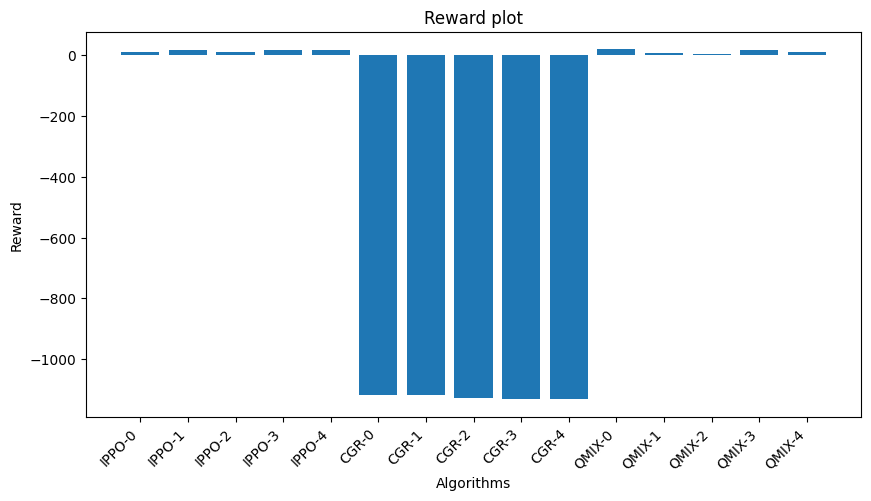

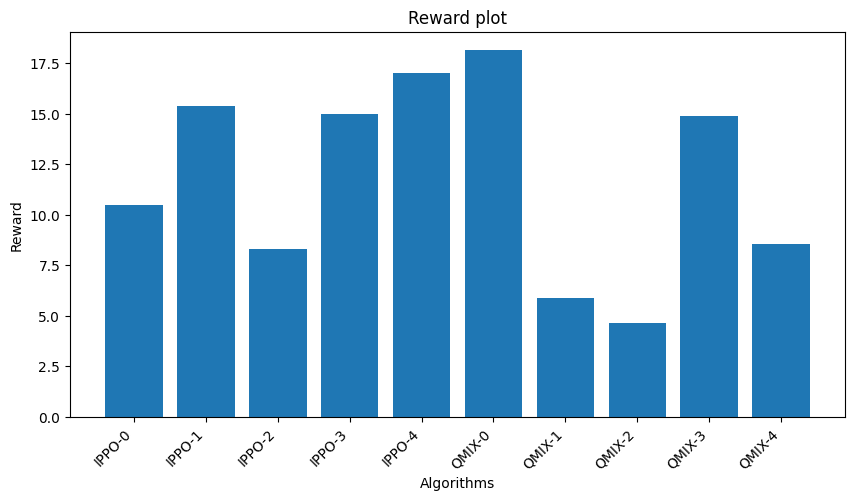

In [46]:
#Template designed with Chatgpt help
#Do bar graphs because BenchMARL only gives us means
values = [ippo0_tr,ippo1_tr,ippo2_tr,ippo3_tr,ippo4_tr, CGR_mean_tr[0],CGR_mean_tr[1],CGR_mean_tr[2],CGR_mean_tr[3],CGR_mean_tr[4], qmix0_tr, qmix1_tr, qmix2_tr, qmix3_tr, qmix4_tr]

x = [0, 1, 2,3,4,5,6,7,8,9,10,11,12,13,14]

labels = ["IPPO-0","IPPO-1","IPPO-2","IPPO-3","IPPO-4", "CGR-0","CGR-1","CGR-2","CGR-3","CGR-4", "QMIX-0","QMIX-1","QMIX-2","QMIX-3","QMIX-4"]
plt.figure(figsize=(10,5))
plt.bar(x, values, tick_label=labels)
plt.xlabel("Algorithms")
plt.ylabel("Reward")
plt.title("Reward plot")
plt.xticks(rotation=45, ha='right')
plt.savefig('Bar_plot_eval.png')

plt.show()
values = [ippo0_tr,ippo1_tr,ippo2_tr,ippo3_tr,ippo4_tr, qmix0_tr, qmix1_tr, qmix2_tr, qmix3_tr, qmix4_tr]

x = [0, 1, 2,3,4,5,6,7,8,9]

labels = ["IPPO-0","IPPO-1","IPPO-2","IPPO-3","IPPO-4","QMIX-0","QMIX-1","QMIX-2","QMIX-3","QMIX-4"]
plt.figure(figsize=(10,5))
plt.bar(x, values, tick_label=labels)
plt.xlabel("Algorithms")
plt.ylabel("Reward")
plt.title("Reward plot")
plt.xticks(rotation=45, ha='right')
plt.savefig('Bar_plot_eval2.png')
plt.show()